In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from ensemble_model import EnsembleModel
import joblib

## 1. Load the Dataset

The Dataset contains one row per completed match.

Each row contains:
- the final match outcome('team0_won')
- aggreagted statistics for both teams
- statistics for each of the six players on each team
- hero an lane assignment

Statistics measured at the 35-minute snapshot.

## 2. Feature Engineering

The engineered features fall into several groups:

### Team compositions and distributions
- Carry share
- Networth standart deviation
- Richest player relative to team avarage

### Team performance
- Team kill/death ratio (KDR)

### Team-to-team differences
- Networth difference
- Damage difference
- Avarage level difference
- Carry networth difference
- KDR difference
- Gold-per-minute difference
- Objective damage difference

### Relative ratios
- Networth ratio
- Damage ratio
- Objective damage ratio

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

new_features = pd.DataFrame({
    "team0_carry_share" : (df["team0_p1_networth"]/df["team0_team_total_networth"]),
    "team1_carry_share" : (df["team1_p1_networth"]/df["team1_team_total_networth"]),
    "team0_networth_std" : df[["team0_p1_networth","team0_p2_networth","team0_p3_networth","team0_p4_networth","team0_p5_networth","team0_p6_networth"]].std(axis=1),
    "team1_networth_std" : df[["team1_p1_networth","team1_p2_networth","team1_p3_networth","team1_p4_networth","team1_p5_networth","team1_p6_networth"]].std(axis=1),
    "team0_team_kdr" : (df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1)),
    "team1_team_kdr" : (df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "team0_richest_vs_team_avg" : (df["team0_p1_networth"]/(df["team0_team_total_networth"]/6)),
    "team1_richest_vs_team_avg" : (df["team1_p1_networth"]/(df["team1_team_total_networth"]/6)),
    'networth_diff': df['team0_team_total_networth'] - df['team1_team_total_networth'],
    "damage_diff":df["team0_team_total_damage"]-df["team1_team_total_damage"],
    "level_diff":df["team0_team_avg_level"]-df["team1_team_avg_level"],
    "carry_diff":df["team0_p1_networth"] - df["team1_p1_networth"],
    "kdr_diff":(df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1))-(df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "gpm_diff" : (df["team0_team_gold_per_minute"]-df["team1_team_gold_per_minute"]),
    "objective_diff" : (df["team0_team_total_objectivedamage"]-df["team1_team_total_objectivedamage"]),
    "networth_ratio" : (df["team0_team_total_networth"]/(df["team1_team_total_networth"]+1)),
    "damage_ratio" : (df["team0_team_total_damage"]/(df["team1_team_total_damage"]+1)),
    "objective_ratio" : (df["team0_team_total_objectivedamage"]/(df["team1_team_total_objectivedamage"]+1))
})
df = pd.concat([df, new_features],axis=1)
print(df.shape)
df


(11308, 202)


,match_id,team0_won,team0_team_total_kills,team0_team_total_deaths,team0_team_total_networth,team0_team_total_damage,team0_team_total_objectivedamage,team0_team_avg_level,team0_team_gold_per_minute,team0_p1_hero,...,networth_diff,damage_diff,level_diff,carry_diff,kdr_diff,gpm_diff,objective_diff,networth_ratio,damage_ratio,objective_ratio
0,1741000,1,62,46,199365,172895,30021,23.500000,949.357116,2,...,3515,20945,0.500000,-5902,0.626841,16.738095,8194,1.017942,1.137834,1.375344
1,30579330,0,61,45,208751,178724,16059,30.500000,994.052353,1,...,437,1680,0.166667,-656,0.622962,2.080952,-20525,1.002093,1.009483,0.438950
2,38763513,1,49,51,228325,174032,21251,28.666667,1087.261874,14,...,10190,765,0.833333,-41,0.019231,48.523808,5890,1.046709,1.004409,1.383349
3,39388145,0,45,49,195655,181129,12994,26.000000,958.623196,31,...,-28395,3270,-0.500000,-18861,-0.079167,-139.122975,-26751,0.873261,1.018380,0.326926
4,39162555,0,42,42,185832,174299,16624,24.833333,884.914260,13,...,-25042,28609,-2.166667,-3040,0.000000,-119.247616,-1718,0.881242,1.196361,0.906286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11303,83270682,0,36,44,212350,185447,16132,32.166667,1011.190447,20,...,-30897,-4327,-1.833333,-10856,-0.300000,-147.128567,-23648,0.872977,0.977194,0.405520
11304,83270698,1,44,22,232964,179884,43850,33.666667,1109.352349,13,...,44261,25333,4.333333,2311,1.424155,210.766661,24473,1.234547,1.163906,2.262875
11305,83270882,0,39,57,215479,192262,11513,32.333333,1049.581070,77,...,-35279,-67619,-2.166667,-17884,-0.594253,-171.841203,-57066,0.859307,0.739805,0.167877
11306,83270880,0,38,58,233759,184686,40742,32.833333,1133.651761,25,...,2450,-60636,-0.500000,5262,-0.628659,11.881668,-3339,1.010588,0.752828,0.924232


## 3. Train/Test Split

The data is split into 80% training and 20% test data

In [ ]:
X = df.drop(columns=["team0_won","match_id"])

y = df["team0_won"]

categorical_columns = []
for team in [0,1]:
    for i in range(1,7):
        categorical_columns.append(f'team{team}_p{i}_hero')
        categorical_columns.append(f'team{team}_p{i}_lane')

X = pd.get_dummies(X, columns=categorical_columns)
feature_columns = joblib.load("YOUR_PATH_HERE")
X = X.reindex(columns=feature_columns, fill_value=0)
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X.columns.to_list()

(11308, 679)


['team0_team_total_kills',
 'team0_team_total_deaths',
 'team0_team_total_networth',
 'team0_team_total_damage',
 'team0_team_total_objectivedamage',
 'team0_team_avg_level',
 'team0_team_gold_per_minute',
 'team0_p1_kills',
 'team0_p1_deaths',
 'team0_p1_assists',
 'team0_p1_networth',
 'team0_p1_damage',
 'team0_p1_creeps',
 'team0_p1_level',
 'team0_p1_objective_damage',
 'team0_p1_denies',
 'team0_p1_gold_per_minute',
 'team0_p1_player_healing',
 'team0_p1_self_healing',
 'team0_p2_kills',
 'team0_p2_deaths',
 'team0_p2_assists',
 'team0_p2_networth',
 'team0_p2_damage',
 'team0_p2_creeps',
 'team0_p2_level',
 'team0_p2_objective_damage',
 'team0_p2_denies',
 'team0_p2_gold_per_minute',
 'team0_p2_player_healing',
 'team0_p2_self_healing',
 'team0_p3_kills',
 'team0_p3_deaths',
 'team0_p3_assists',
 'team0_p3_networth',
 'team0_p3_damage',
 'team0_p3_creeps',
 'team0_p3_level',
 'team0_p3_objective_damage',
 'team0_p3_denies',
 'team0_p3_gold_per_minute',
 'team0_p3_player_healing'

## 4. Baseline Performance

As an initial benchmark, an XGB classifier and RandomForest classifier are trained with a relatively simple configurations.

The baseline models achive roughly 84.5% test accuracy

In [ ]:
model_xgb = XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,random_state=42)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy_xgb}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.8465959328028294

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1118
           1       0.85      0.85      0.85      1144

    accuracy                           0.85      2262
   macro avg       0.85      0.85      0.85      2262
weighted avg       0.85      0.85      0.85      2262



In [5]:
importance = pd.DataFrame({"feature": X.columns, "importance": model_xgb.feature_importances_})

importance = importance.sort_values(by="importance",ascending=False)

importance

,feature,importance
166,networth_diff,0.228104
173,networth_ratio,0.065764
171,gpm_diff,0.022460
168,level_diff,0.015508
172,objective_diff,0.014665
...,...,...
634,team1_p5_lane_3,0.000000
633,team1_p5_lane_1,0.000000
632,team1_p5_hero_81,0.000000
631,team1_p5_hero_80,0.000000


In [ ]:
model_rf = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42)

model_rf.fit(X_train, y_train)

rf_predictions = model_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy}")

print("\nRandom Forest Report:")

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.845711759504863

Random Forest Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1118
           1       0.84      0.85      0.85      1144

    accuracy                           0.85      2262
   macro avg       0.85      0.85      0.85      2262
weighted avg       0.85      0.85      0.85      2262



In [7]:
rf_importance = pd.DataFrame({"feature": X.columns,"importance": model_rf.feature_importances_})

rf_importance = rf_importance.sort_values(by="importance",ascending=False)

print(rf_importance.head(20))

                              feature  importance
173                    networth_ratio    0.064635
166                     networth_diff    0.064504
168                        level_diff    0.042769
171                          gpm_diff    0.040677
175                   objective_ratio    0.036313
172                    objective_diff    0.036178
169                        carry_diff    0.026236
85         team1_team_gold_per_minute    0.021383
2           team0_team_total_networth    0.019022
162                    team0_team_kdr    0.018023
83   team1_team_total_objectivedamage    0.016443
6          team0_team_gold_per_minute    0.016332
81          team1_team_total_networth    0.015777
58                  team0_p5_networth    0.014969
46                  team0_p4_networth    0.014902
163                    team1_team_kdr    0.014491
52           team0_p4_gold_per_minute    0.013454
170                          kdr_diff    0.013292
143          team1_p5_gold_per_minute    0.012395


## 5. Tuned XGBoost

The next experiment uses a more regularized XGBoost configuration.

In [ ]:
model_xgb = XGBClassifier(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.03,

    subsample=0.7,

    colsample_bytree=0.7,

    min_child_weight=7,

    gamma=2,

    reg_alpha=2,

    reg_lambda=10,

    random_state=42,
)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.8514588859416445

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1118
           1       0.85      0.85      0.85      1144

    accuracy                           0.85      2262
   macro avg       0.85      0.85      0.85      2262
weighted avg       0.85      0.85      0.85      2262



The tuned model achives ~85% test accuracy and ~89% train accuracy

In [ ]:
train_acc = model_xgb.score(X_train, y_train)

test_acc = model_xgb.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.8911120937430909
0.8514588859416445


### 6. ROC-AUC

Because the final application outputs a win probability rather than only a binary prediction, accuracy alone is not sufficient.

ROC-AUC measures how well the model ranks winning teams above losing teams across different probability thresholds.

For the tuned XGBoost model, the test ROC-AUC is approximately 0.928.

In [ ]:
from sklearn.metrics import roc_auc_score

probs=model_xgb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,probs))

0.9286398976694147


## 7. CatBoost

CatBoost is evaluated as a second gradient-boosting model.

It recieves approximately 85.2% test accuracy and 0.929 ROC-AUC score.

In [ ]:
model_cat = CatBoostClassifier(

    iterations=1500,

    depth=4,

    learning_rate=0.02,

    l2_leaf_reg=15,

    min_data_in_leaf=30,

    random_strength=5,

    bagging_temperature=2,

    verbose=100,

    random_seed=42
)

model_cat.fit(X_train, y_train)

probs = model_cat.predict_proba(X_test)[:,1]

predictions = model_cat.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for CAT: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

pred=(probs>0.5)

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs))

0:	learn: 0.6827784	total: 153ms	remaining: 3m 49s
100:	learn: 0.3789961	total: 705ms	remaining: 9.76s
200:	learn: 0.3563479	total: 1.21s	remaining: 7.84s
300:	learn: 0.3485025	total: 1.72s	remaining: 6.84s
400:	learn: 0.3442156	total: 2.22s	remaining: 6.08s
500:	learn: 0.3391694	total: 2.74s	remaining: 5.46s
600:	learn: 0.3316568	total: 3.24s	remaining: 4.85s
700:	learn: 0.3228968	total: 3.75s	remaining: 4.27s
800:	learn: 0.3149126	total: 4.27s	remaining: 3.73s
900:	learn: 0.3068080	total: 4.78s	remaining: 3.18s
1000:	learn: 0.3001835	total: 5.28s	remaining: 2.63s
1100:	learn: 0.2935616	total: 5.78s	remaining: 2.09s
1200:	learn: 0.2869912	total: 6.28s	remaining: 1.56s
1300:	learn: 0.2808806	total: 6.82s	remaining: 1.04s
1400:	learn: 0.2750815	total: 7.32s	remaining: 517ms
1499:	learn: 0.2699682	total: 7.82s	remaining: 0us
Accuracy for CAT: 0.852343059239611

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      

In [ ]:
train_acc = model_cat.score(X_train, y_train)

test_acc = model_cat.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.8863586115410126
0.852343059239611


## 8. Ensemble Model

The final predictor combines the XGBoost and CatBoost models using simple soft-voting ensemble. For each match, both models produce class probabilities, which are then avaraged using arithmetic mean.

On the test set ensemble achieves approxiamtely 85.1% accuracy and 0.929 ROC-AUC score.

In [ ]:
ensemble = EnsembleModel(model_xgb, model_cat)
joblib.dump(ensemble, 'YOUR_PATH_HERE')

pred = ensemble.predict(X_test)
probs = ensemble.predict_proba(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs[:, 1]))

0.8510167992926614
0.9294772758547356


## 9. Calibration Curve

A calibration curve compares predicted probabilities with the observed frequency of the positive class.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_xgb, method='isotonic', cv=5)

calibrated.fit(X_train, y_train)

probs = calibrated.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, probs))

0.9290292667976032


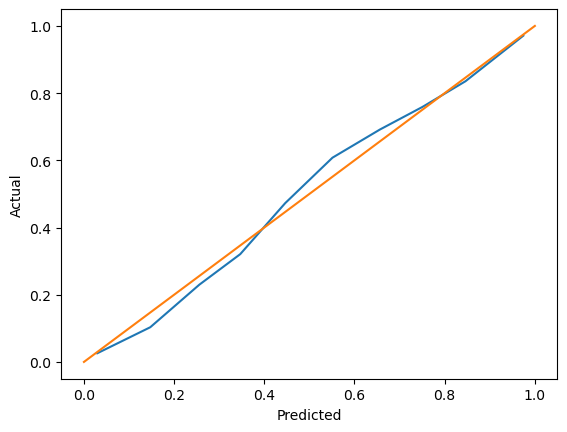

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true)

plt.plot([0,1], [0,1])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 10. Model Explainability with SHAP

SHAP is used to investigate which features influence the XGBoost predictions.

Two visualizations are produced:

1. A SHAP summary plot showing the overall importance and direction of feature contributions.
2. A bar plot showing aggregated feature importance.

This provides an interpretable view of which aspects of the game influance the model prediction the most.

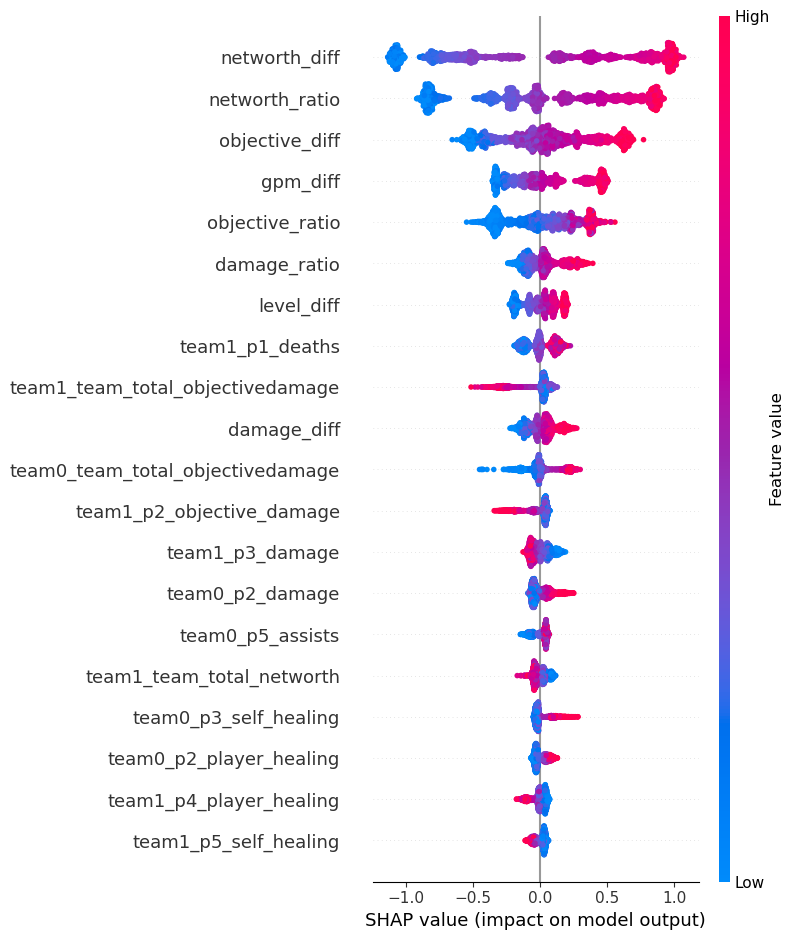

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = (explainer.shap_values(X_test))

shap.summary_plot(shap_values,X_test)

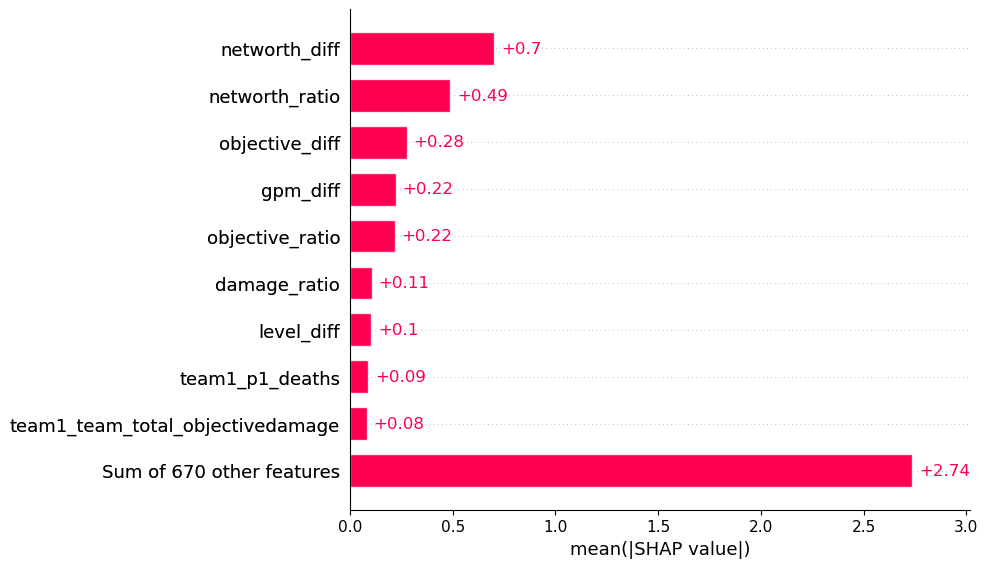

In [ ]:
shap.plots.bar(shap.Explanation(values=shap_values, data=X_test.values, feature_names=X_test.columns))